In [10]:
import numpy as np
import torch
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
import importlib
import dataset
from image_builder import *
from data_prepare import *
import data_fetch
from data_fetch import *
from data_fetch import _download_single, _read_mops_csv

importlib.reload(dataset)
importlib.reload(data_fetch)

<module 'data_fetch' from '/home/iof_314707035/Jasper/Reimage_price_trends/data_fetch.py'>

In [11]:
from dataset import *
import os

START = "1993-01-01"
END = "1998-12-31"
TRAIN_END = "1996-12-31"
SAVE_DIR = "data"
Market = "US_1993_2020"
I = 5
R = 5
CRSP_DATA_DIR = resolve_crsp_data_dir()
print("CRSP data dir:", CRSP_DATA_DIR)

TICKERS, crsp_info = get_crsp_permno_universe(
    crsp_data_dir=CRSP_DATA_DIR,
    start=START,
    end=END,
    return_info=True,
)

print("permno 數量:", len(TICKERS))
display(crsp_info.head())

CRSP data dir: us_stock
permno 數量: 12720


,ticker,permno,first_year,last_year,rows
0,10001,10001,1993,1998,1161
1,10002,10002,1993,1998,560
2,10003,10003,1993,1995,665
3,10009,10009,1993,1998,996
4,10010,10010,1993,1995,670


In [ ]:
'''
X_trainval, y_trainval, X_test, y_test, meta = build_research_dataset(
    tickers=TICKERS,
    start=START,
    end=END,
    I=I,
    R=R,
    train_end=TRAIN_END,
    save_dir=SAVE_DIR,
    Market=Market,
    price_source="crsp",
    crsp_data_dir=CRSP_DATA_DIR,
    checkpoint_every=1,
    resume=False,
    process_by="year",
    checkpoint_save_arrays=False,
    year_ticker_chunk_size=1000,
    max_workers=8,
)
'''


Year-based CRSP build: pending years=[1993, 1994, 1995, 1996, 1997, 1998]

[I5/R5] build year: 1993


year 1993 chunks: 100%|██████████| 13/13 [03:28<00:00, 16.01s/it]


  done year 1993: 333280 images
  Checkpoint saved: 1 tickers done, 333280 images

[I5/R5] build year: 1994


year 1994 chunks: 100%|██████████| 13/13 [04:41<00:00, 21.65s/it]


  done year 1994: 368862 images
  Checkpoint saved: 2 tickers done, 702142 images

[I5/R5] build year: 1995


...

  done year 1996: 410908 images
  Checkpoint saved: 4 tickers done, 1498421 images

[I5/R5] build year: 1997


year 1997 chunks: 100%|██████████| 13/13 [05:22<00:00, 24.79s/it]


  done year 1997: 431698 images
  Checkpoint saved: 5 tickers done, 1930119 images

[I5/R5] build year: 1998


year 1998 chunks: 100%|██████████| 13/13 [05:20<00:00, 24.67s/it]


  done year 1998: 429915 images
  Checkpoint saved: 6 tickers done, 2360034 images
  Checkpoint saved: 6 tickers done, 2360034 images

總樣本數: 2360034
標籤分布: up=0.482, down=0.518
  Train+Val: 1498421  (up=0.483)
  Test     : 861613  (up=0.480)

撌脣摮 data/training_data/US_1993_2020/I5R5S5_week/


In [12]:
I = 5
R = 5
Market = "US_1993_2020"

dataset_dir = f"data/training_data/{Market}/I{I}R{R}S{R}_week"

X_trainval = np.load(f"{dataset_dir}/X_trainval.npy")
y_trainval = np.load(f"{dataset_dir}/y_trainval.npy")

X_test = np.load(f"{dataset_dir}/X_test.npy")
y_test = np.load(f"{dataset_dir}/y_test.npy")

meta = pd.read_csv(f"{dataset_dir}/meta.csv")
meta_trainval = pd.read_csv(f"{dataset_dir}/meta_trainval.csv")
meta_test = pd.read_csv(f"{dataset_dir}/meta_test.csv")

print("X_trainval:", X_trainval.shape)
print("y_trainval:", y_trainval.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

print("meta_trainval:", meta_trainval.shape)
print("meta_test:", meta_test.shape)

display(meta.head())



X_trainval: (1498421, 32, 15)
y_trainval: (1498421,)
X_test: (861613, 32, 15)
y_test: (861613,)
meta_trainval: (1498421, 12)
meta_test: (861613, 12)


,ticker,start_date,date,label_end_date,label,ret,I,R,sample_step,sample_freq,price_source,ending_date
0,10001,1993-01-14,1993-01-22,1993-02-09,0,-0.018170,5,5,5,week,crsp,1993-01-22
1,10001,1993-02-02,1993-02-12,1993-03-01,1,0.054209,5,5,5,week,crsp,1993-02-12
2,10001,1993-02-12,1993-02-26,1993-03-11,1,0.020092,5,5,5,week,crsp,1993-02-26
3,10001,1993-03-08,1993-03-12,1993-03-23,0,-0.052392,5,5,5,week,crsp,1993-03-12
4,10001,1993-03-25,1993-04-08,1993-04-19,1,0.044248,5,5,5,week,crsp,1993-04-08


In [13]:
import model
importlib.reload(model)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


Using device: cuda


In [14]:
RUN_SEEDS = list(range(1))
ENSEMBLE_DIR = f"models/{Market}/I{I}R{R}"
EPOCHS = 50
BATCH_SIZE = 128
VAL_RATIO = 0.3

ensemble_results = model.train_resplit_ensemble(
    X_trainval=X_trainval,
    y_trainval=y_trainval,
    I=I,
    R=R,
    seeds=RUN_SEEDS,
    save_dir=ENSEMBLE_DIR,
    Market=Market,
    val_ratio=VAL_RATIO,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    lr=1e-4,
    weight_decay=1e-4,
    device=device,
)


ensemble runs:   0%|          | 0/1 [00:00<?, ?it/s, seed=0]/home/iof_314707035/miniconda3/envs/reimage-price-trends/lib/python3.11/site-packages/torch/cuda/__init__.py:435: UserWarning: 
    Found GPU0 NVIDIA GB10 which is of cuda capability 12.1.
    Minimum and Maximum cuda capability supported by this version of PyTorch is
    (7.5) - (12.0)
    
  queued_call()
ensemble runs: 100%|██████████| 1/1 [19:20<00:00, 1160.10s/it, seed=0]


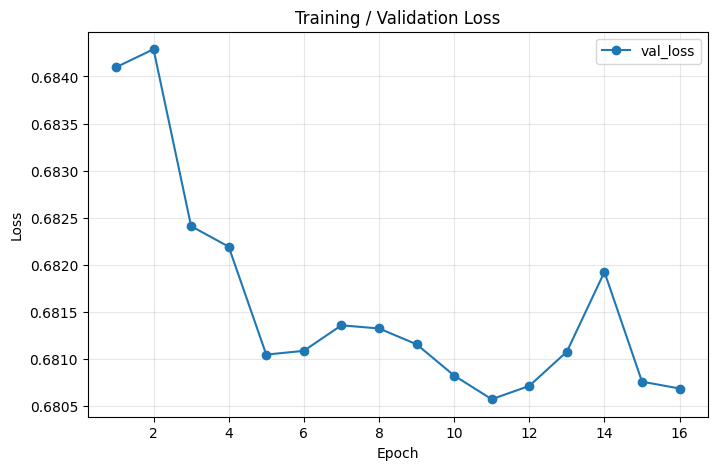

In [4]:
import torch
import pandas as pd
import matplotlib.pyplot as plt


result = pd.read_csv("/home/iof_314707035/Jasper/Reimage_price_trends/models/US_1993_2020/I5R5/US_1993_2020_training_history_I5R5_seed0.csv")

plt.figure(figsize=(8, 5))
plt.plot(result["epoch"], result["val_loss"], label="val_loss", marker="o")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training / Validation Loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


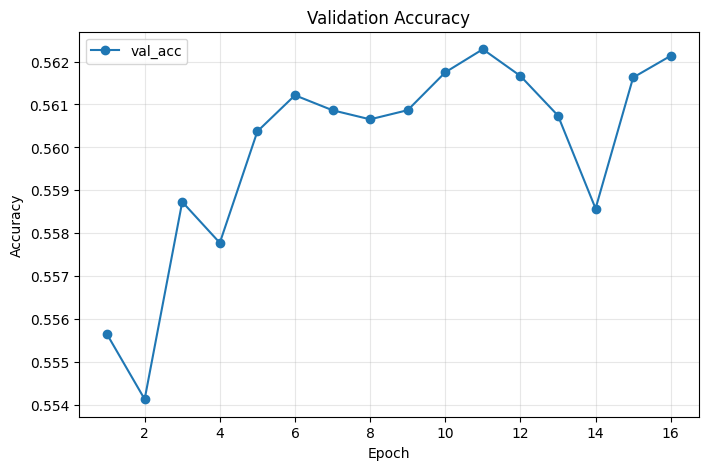

In [6]:
plt.figure(figsize=(8, 5))
plt.plot(result["epoch"], result["val_acc"], label="val_acc", marker="o")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Validation Accuracy")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Test

In [8]:
from pathlib import Path
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error, accuracy_score, log_loss
import model

root = Path("/home/iof_314707035/Jasper")

# 1. 讀取 test data
market = "US_1993_2020"
dataset_dir = root / "Reimage_price_trends" / "data" / "training_data" / market / "I5R5S5_week"

X_test = np.load(dataset_dir / "X_test.npy")
y_test = np.load(dataset_dir / "y_test.npy")

print(X_test.shape, y_test.shape)


(861613, 32, 15) (861613,)


In [15]:
summary_path = root / "Reimage_price_trends" / "models" / "US_1993_2020" / "I5R5" / "US_1993_2020_training_summary_I5R5_seed0.csv"
summary_df = pd.read_csv(summary_path)
best_path = summary_df.loc[0, "best_path"]
print(best_path)


models/US_1993_2020/I5R5/US_1993_2020_best_model_I5R5_seed0.pth


In [16]:
pred_prob = model.predict_proba_from_checkpoint(
    X_test,
    best_path,
    batch_size=128,
    device="cpu",   # 有 GPU 可改成 "cuda"
)

pred_prob = np.asarray(pred_prob).reshape(-1)
pred_label = (pred_prob > 0.5).astype(int)


In [17]:
test_mse = mean_squared_error(y_test, pred_prob)
test_acc = accuracy_score(y_test, pred_label)
test_logloss = log_loss(y_test, pred_prob)

print("best checkpoint:", best_path)
print("test MSE:", test_mse)
print("test accuracy:", test_acc)
print("test logloss:", test_logloss)


best checkpoint: models/US_1993_2020/I5R5/US_1993_2020_best_model_I5R5_seed0.pth
test MSE: 0.24745085835456848
test accuracy: 0.5375719725677305
test logloss: 0.6880068443248374


In [18]:
test_result_df = pd.DataFrame({
    "y_true": y_test,
    "pred_prob": pred_prob,
    "pred_label": pred_label,
})

test_result_df.head()


,y_true,pred_prob,pred_label
0,1,0.369212,0
1,1,0.234479,0
2,0,0.603475,1
3,0,0.268961,0
4,0,0.552041,1
